In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_parquet('/content/drive/MyDrive/jaipur_simulated_90d.parquet')
df.head(5)

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,solar_output_mw,clear_sky_ghi,hour,day_of_week,month,is_daytime
2024-01-01 00:00:00+05:30,13.970189,43.980991,0.0,20.960569,3.879269,0.0,0.0,0.0,0.0,0.0,0,0,1,False
2024-01-01 01:00:00+05:30,13.839103,30.442062,0.0,13.340828,3.626454,0.0,0.0,0.0,0.0,0.0,1,0,1,False
2024-01-01 02:00:00+05:30,15.830424,35.154587,0.0,22.772263,6.618362,0.0,0.0,0.0,0.0,0.0,2,0,1,False
2024-01-01 03:00:00+05:30,12.384981,39.644611,0.0,33.276360,6.435849,0.0,0.0,0.0,0.0,0.0,3,0,1,False
2024-01-01 04:00:00+05:30,12.856221,44.587589,0.0,12.190160,4.275191,0.0,0.0,0.0,0.0,0.0,4,0,1,False


In [35]:
df.shape

(2160, 14)

In [36]:
df.tail(5)

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,solar_output_mw,clear_sky_ghi,hour,day_of_week,month,is_daytime
2024-03-30 19:00:00+05:30,27.853397,27.734514,0.0,7.603663,7.096019,0.0,0.0,0.0,0.0,0.0,19,5,3,True
2024-03-30 20:00:00+05:30,26.555773,40.595531,0.0,10.497643,8.736644,0.0,0.0,0.0,0.0,0.0,20,5,3,False
2024-03-30 21:00:00+05:30,21.977415,30.833113,0.0,11.187419,3.786086,0.0,0.0,0.0,0.0,0.0,21,5,3,False
2024-03-30 22:00:00+05:30,21.705753,39.193600,0.0,30.379726,3.878497,0.0,0.0,0.0,0.0,0.0,22,5,3,False
2024-03-30 23:00:00+05:30,21.714672,33.562309,0.0,21.692293,4.618655,0.0,0.0,0.0,0.0,0.0,23,5,3,False


In [37]:
df.dtypes

,0
temperature_2m,float32
relative_humidity_2m,float32
precipitation,float32
cloud_cover,float32
wind_speed_10m,float32
shortwave_radiation,float32
direct_radiation,float32
diffuse_radiation,float32
solar_output_mw,float32
clear_sky_ghi,float32


In [38]:
df.isnull().sum()

,0
temperature_2m,0
relative_humidity_2m,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
shortwave_radiation,0
direct_radiation,0
diffuse_radiation,0
solar_output_mw,0
clear_sky_ghi,0


In [39]:
df.isnull().mean()*100

,0
temperature_2m,0.0
relative_humidity_2m,0.0
precipitation,0.0
cloud_cover,0.0
wind_speed_10m,0.0
shortwave_radiation,0.0
direct_radiation,0.0
diffuse_radiation,0.0
solar_output_mw,0.0
clear_sky_ghi,0.0


In [40]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,solar_output_mw,clear_sky_ghi,hour,day_of_week,month
count,2160.000000,2160.000000,2160.0,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,23.882168,35.587875,0.0,15.958865,5.039747,230.239532,186.347244,83.748489,18.031927,231.441147,11.500000,2.966667,1.988889
std,7.022980,6.253275,0.0,10.867751,1.560439,279.430084,226.533447,102.662964,21.773327,280.783478,6.923789,1.986243,0.823388
min,7.587507,15.000000,0.0,0.000000,3.500237,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,18.813428,31.269951,0.0,7.526283,3.935871,0.000000,0.000000,0.000000,0.000000,0.000000,5.750000,1.000000,1.000000
50%,23.942057,35.423258,0.0,15.342380,4.532325,40.199993,29.938623,12.566592,2.911029,42.421013,11.500000,3.000000,2.000000
75%,28.875888,39.879292,0.0,23.075295,5.649645,496.274567,402.270401,180.681011,38.950224,494.176788,17.250000,5.000000,3.000000
max,41.647449,58.957909,0.0,61.232777,14.473863,809.728210,685.228027,365.192108,62.500320,793.155884,23.000000,6.000000,3.000000


In [41]:
df.groupby('is_daytime')['solar_output_mw'].describe()

,count,mean,std,min,25%,50%,75%,max
is_daytime,,,,,,,,
False,900.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000,0.00000
True,1260.0,30.911873,20.3598,0.0,7.945118,34.652309,48.996161,62.50032


In [42]:
print("Max solar output:", df['solar_output_mw'].max())
print("Mean solar output:", df['solar_output_mw'].mean())
print("Max irradiance:", df['shortwave_radiation'].max())
print("\nDaytime rows only:")
print(df[df['is_daytime'] == True]['solar_output_mw'].describe())

Max solar output: 62.50032043457031
Mean solar output: 18.031927
Max irradiance: 809.7282104492188

Daytime rows only:
count    1260.000000
mean       30.911873
std        20.359800
min         0.000000
25%         7.945118
50%        34.652309
75%        48.996161
max        62.500320
Name: solar_output_mw, dtype: float64


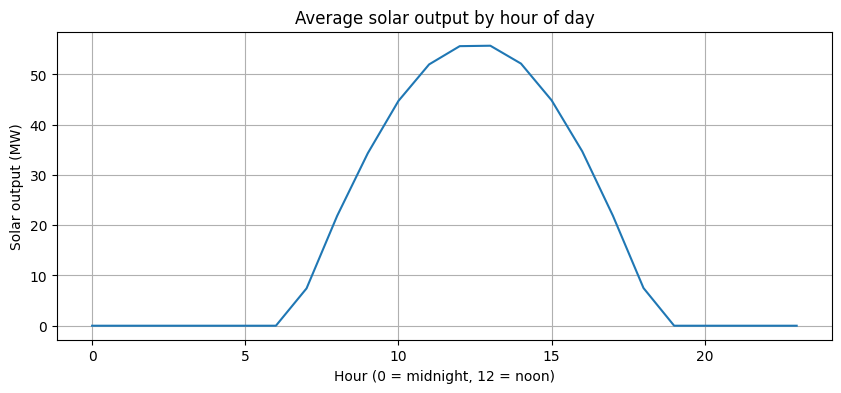

In [43]:
hourly_avg = df.groupby('hour')['solar_output_mw'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg)
plt.title('Average solar output by hour of day')
plt.xlabel('Hour (0 = midnight, 12 = noon)')
plt.ylabel('Solar output (MW)')
plt.grid(True)
plt.show()

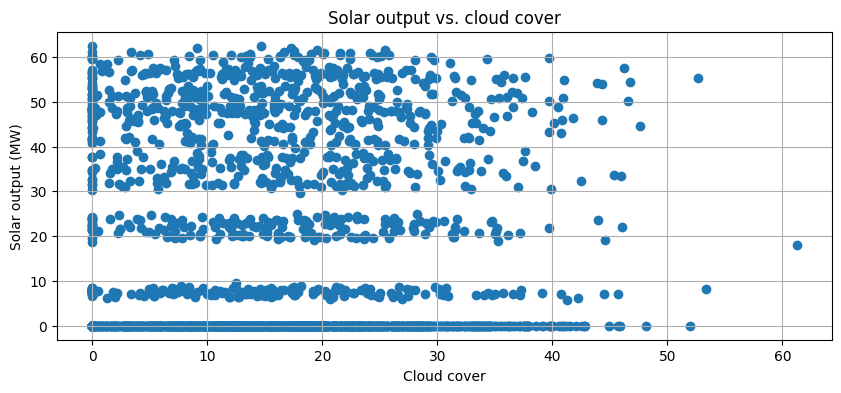

In [44]:

daytime = df[df['is_daytime'] == True]

plt.figure(figsize=(10, 4))
plt.scatter(df['cloud_cover'], df['solar_output_mw'])
plt.title('Solar output vs. cloud cover')
plt.xlabel('Cloud cover')
plt.ylabel('Solar output (MW)')
plt.grid(True)
plt.show()

In [45]:
print("Max output:", df['solar_output_mw'].max())
print("Min output:", df['solar_output_mw'].min())

Max output: 62.50032043457031
Min output: 0.0


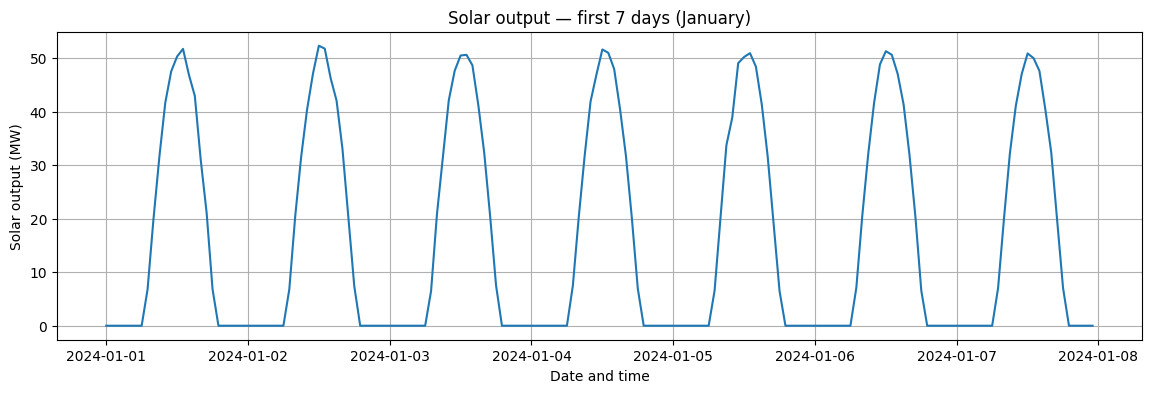

In [46]:
one_week = df.iloc[:168]
plt.figure(figsize=(14, 4))
plt.plot(one_week.index, one_week['solar_output_mw'])
plt.title('Solar output — first 7 days (January)')
plt.xlabel('Date and time')
plt.ylabel('Solar output (MW)')
plt.grid(True)
plt.show()

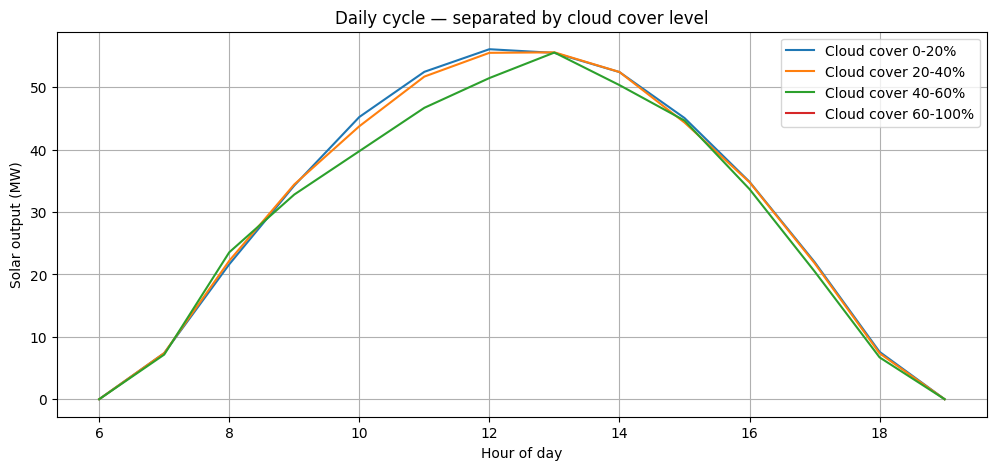

In [47]:
df['cloud_bucket'] = pd.cut(df['cloud_cover'],
                             bins=[0, 20, 40, 60, 100],
                             labels=['0-20%', '20-40%', '40-60%', '60-100%'])

daytime = df[df['is_daytime'] == True]

plt.figure(figsize=(12, 5))
for bucket in ['0-20%', '20-40%', '40-60%', '60-100%']:
    subset = daytime[daytime['cloud_bucket'] == bucket]
    hourly = subset.groupby('hour')['solar_output_mw'].mean()
    plt.plot(hourly, label=f'Cloud cover {bucket}')

plt.title('Daily cycle — separated by cloud cover level')
plt.xlabel('Hour of day')
plt.ylabel('Solar output (MW)')
plt.legend()
plt.grid(True)
plt.show()

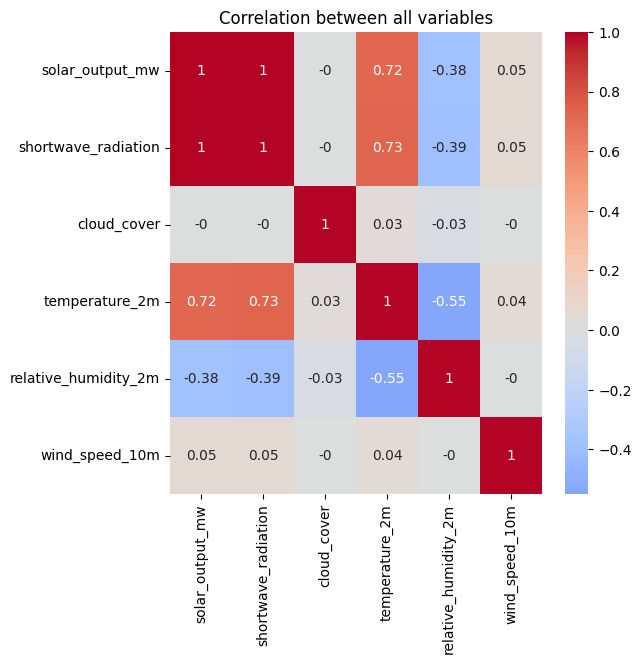

In [49]:
cols = ['solar_output_mw', 'shortwave_radiation',
        'cloud_cover', 'temperature_2m',
        'relative_humidity_2m', 'wind_speed_10m']

corr = df[cols].corr().round(2)

plt.figure(figsize=(6, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between all variables')
plt.show()


month
1    16.549999
2    18.120001
3    19.469999
Name: solar_output_mw, dtype: float32


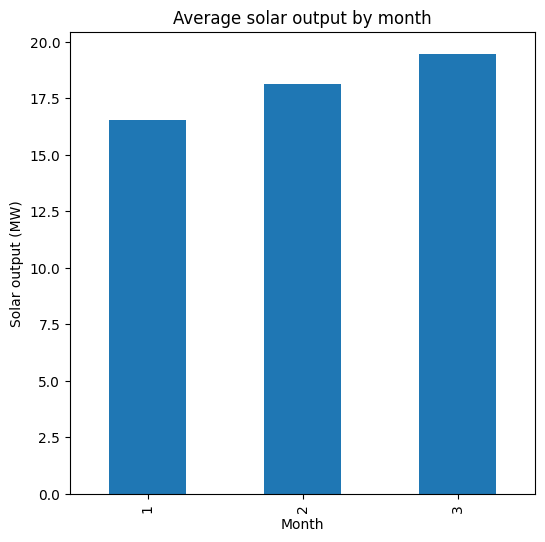

In [51]:
plt.figure(figsize=(6, 6))
monthly_avg = df.groupby('month')['solar_output_mw'].mean().round(2)
print(monthly_avg)

monthly_avg.plot(kind='bar',
                 title='Average solar output by month',
                 ylabel='Solar output (MW)',
                 xlabel='Month')
plt.show()